# Programa para depuración de datos obtenidos mediante el acelerómetro

Este programa obtiene la velocidad de giro del sistema en rad/s para cada tiempo y la representa como $\Omega$ en función de $t$. Calcula también el valor promedio de la velocidad angular.

Se ha de ingresar únicamente el archivo obtenido mediante el acelerómetro.

C:\Users\ruizm\AppData\Local\Temp\ipykernel_3296\1118494384.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tiempo_dt = pd.to_datetime(resultado['Tiempo'], errors='coerce')


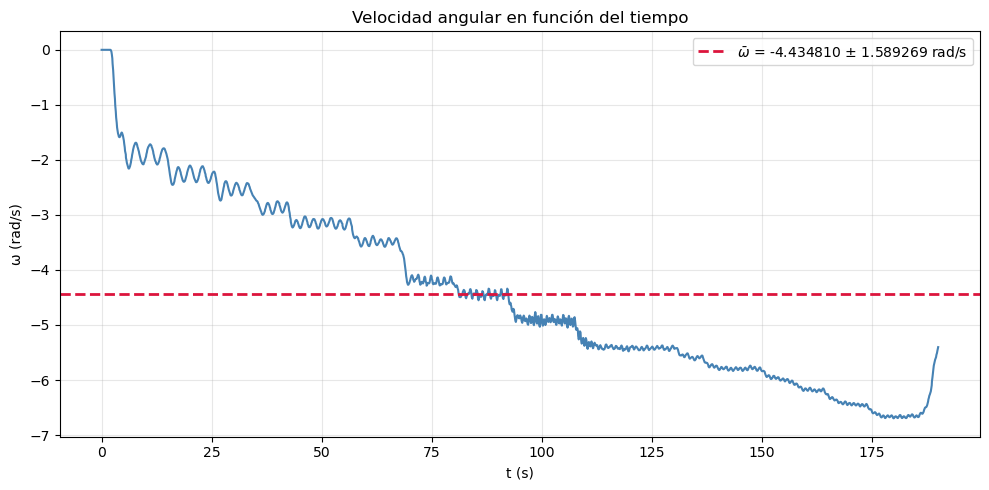

$\bar{\omega}$ = -4.434810 ± 1.589269 rad/s


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



########################################################################################################
#********************INGRESE EL NOMBRE DE ARCHIVO DE ENTRADA PROPORCIONADO POR EL ACELERÓMETRO**********
########################################################################################################
archivo_entrada = 'w_antihoraria.txt'


#********************PROCESAMIENTO DE DATOS Y GRAFICACIÓN********************

# El acelerómetro registra datos con formato csv, para extraerlos se usa:
datos = pd.read_csv(archivo_entrada, sep=',', index_col=False, skipinitialspace=True, low_memory=False)

# Seleccionamos (Columna 0 es Tiempo, Columna 7 es Vel. Angular Y)
resultado = datos.iloc[:, [0, 7]].copy()

resultado.columns = ['Tiempo', 'Velocidad_Angular_grados'] 

# Leo la columna del tiempo que se encuentra en formato de horas minutos y segundos
resultado['Tiempo'] = resultado['Tiempo'].astype(str).str.strip()
tiempo_dt = pd.to_datetime(resultado['Tiempo'], format='%H:%M:%S', errors='coerce')
if tiempo_dt.isna().all():
    tiempo_dt = pd.to_datetime(resultado['Tiempo'], errors='coerce')


# Convertir a segundos relativos tomando la primera fila como t=0
tiempo_inicial = tiempo_dt.iloc[0] # Guardo el primer tiempo de la columna, el cual es el instate inicial
tiempo = (tiempo_dt - tiempo_inicial).dt.total_seconds()
resultado['Tiempo_s'] = tiempo.values

# Convertir velocidad a numérica y a rad/s (inicialmente esta en grados/s)
resultado['Velocidad_Angular_grados'] = pd.to_numeric(resultado['Velocidad_Angular_grados'], errors='coerce')
resultado = resultado.dropna(subset=['Velocidad_Angular_grados', 'Tiempo_s'])
resultado['Velocidad_Angular_rad_s'] = resultado['Velocidad_Angular_grados'] * (np.pi / 180)

# Reordeno columnas
resultado = resultado[['Tiempo_s', 'Velocidad_Angular_grados', 'Velocidad_Angular_rad_s']]

# Calcular la media y desviación estándar de la tercera columna
media_tercera_columna = resultado['Velocidad_Angular_rad_s'].mean()
std_media = resultado['Velocidad_Angular_rad_s'].std()


# *********Graficar la tercera columna en función del tiempo y marcar la media*********
plt.figure(figsize=(10, 5))
plt.plot(resultado['Tiempo_s'], resultado['Velocidad_Angular_rad_s'], color='steelblue')
plt.axhline(media_tercera_columna, color='crimson', linestyle='--', linewidth=2, label=f'$\\bar{{\\omega}}$ = {media_tercera_columna:.6f} ± {std_media:.6f} rad/s')
plt.xlabel('t (s)')
plt.ylabel('ω (rad/s)')
plt.title('Velocidad angular en función del tiempo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"$\\bar{{\\omega}}$ = {media_tercera_columna:.6f} ± {std_media:.6f} rad/s")
